# Notebook Setup

In [890]:
!which python

/Users/user/Desktop/mlProjects/.venv/bin/python


In [891]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

In [892]:
 sns.set()

# Load dataset

In [893]:
data = datasets.load_iris()

In [894]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [895]:
print(data['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [896]:
data['data'][:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [897]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [898]:
data['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

## What problem are we tryint to solve?
We are trying to predict the species of flower, using its attributes.  Specificially, we are using these 

attributes: 
- sepal length and width
- pedal length and width

- Classes: 'setosa', 'versicolor', 'virginica'

# Create a pandas DataFrame from the data

In [899]:
df = pd.DataFrame(data['data'], columns = data['feature_names'])
df['target'] = data['target']
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Basic descriptive statistics

In [900]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# Distirbutions of features and target

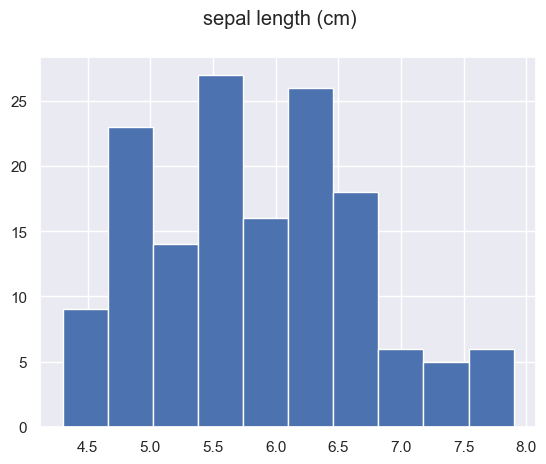

In [901]:
col = "sepal length (cm)"
df[col].hist()
plt.suptitle(col)
plt.show()

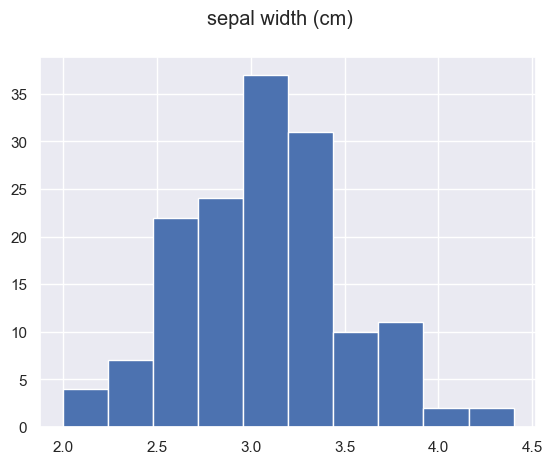

In [902]:
col = "sepal width (cm)"
df[col].hist()
plt.suptitle(col)
plt.show()

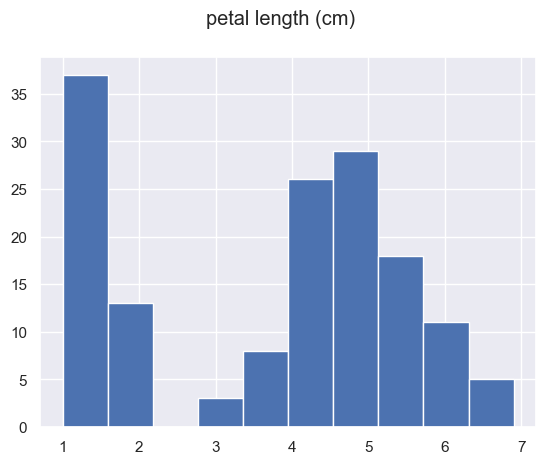

In [903]:
col = "petal length (cm)"
df[col].hist()
plt.suptitle(col)
plt.show()

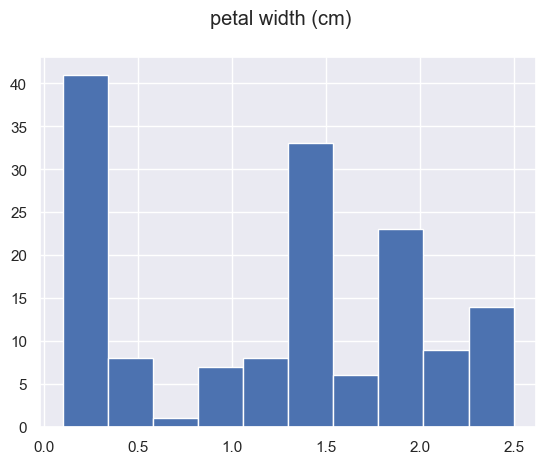

In [904]:
col = "petal width (cm)"
df[col].hist()
plt.suptitle(col)
plt.show()

# Relationship of data features with the target

In [905]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [906]:
#creating a new columns with species' names
df['target_names'] = df['target'].map({0:'setosa', 1:'versicolor', 2:'virginica'})
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


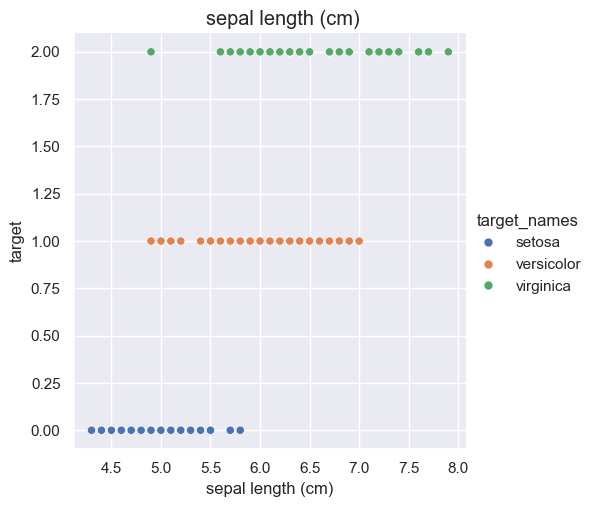

In [907]:
col = 'sepal length (cm)'
sns.relplot(x = col, y = 'target', hue = 'target_names', data = df)
plt.suptitle(col, y = 1.01)
plt.show()

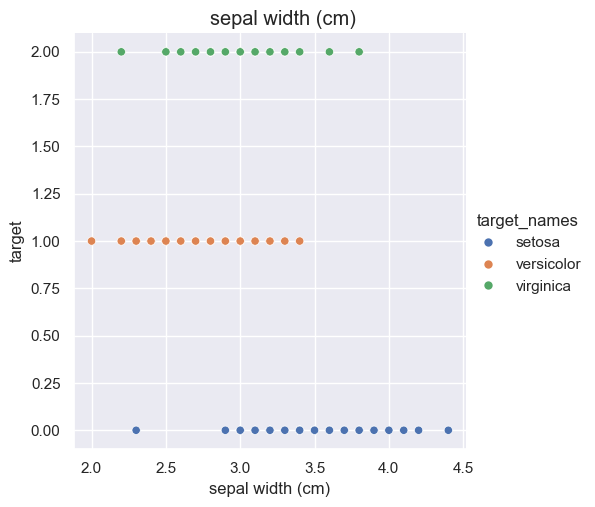

In [908]:
col = 'sepal width (cm)'
sns.relplot(x = col, y = 'target', hue = 'target_names', data = df)
plt.suptitle(col, y = 1.01)
plt.show()

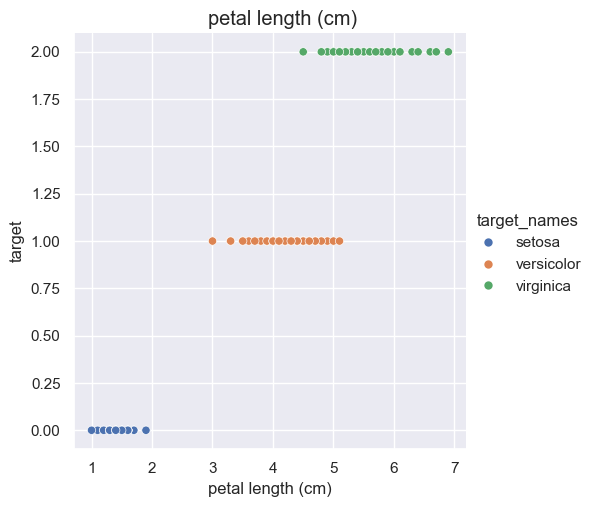

In [909]:
col = 'petal length (cm)'
sns.relplot(x = col, y = 'target', hue = 'target_names', data = df)
plt.suptitle(col, y = 1.01)
plt.show()

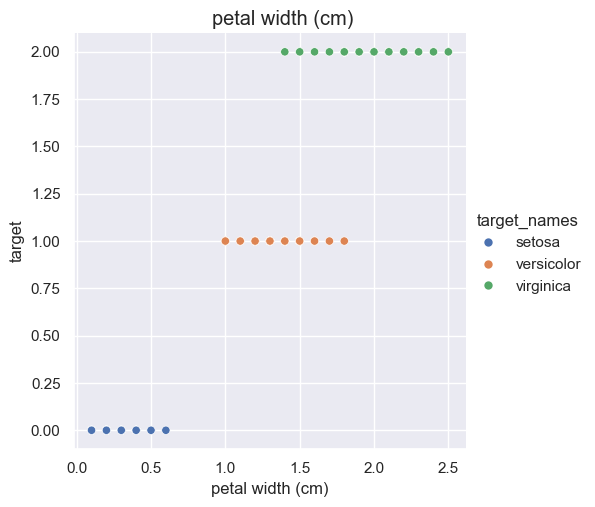

In [910]:
col = 'petal width (cm)'
sns.relplot(x = col, y = 'target', hue = 'target_names', data = df)
plt.suptitle(col, y = 1.01)
plt.show()

# Exploratory Data Analysis (EDA) - Pairplots

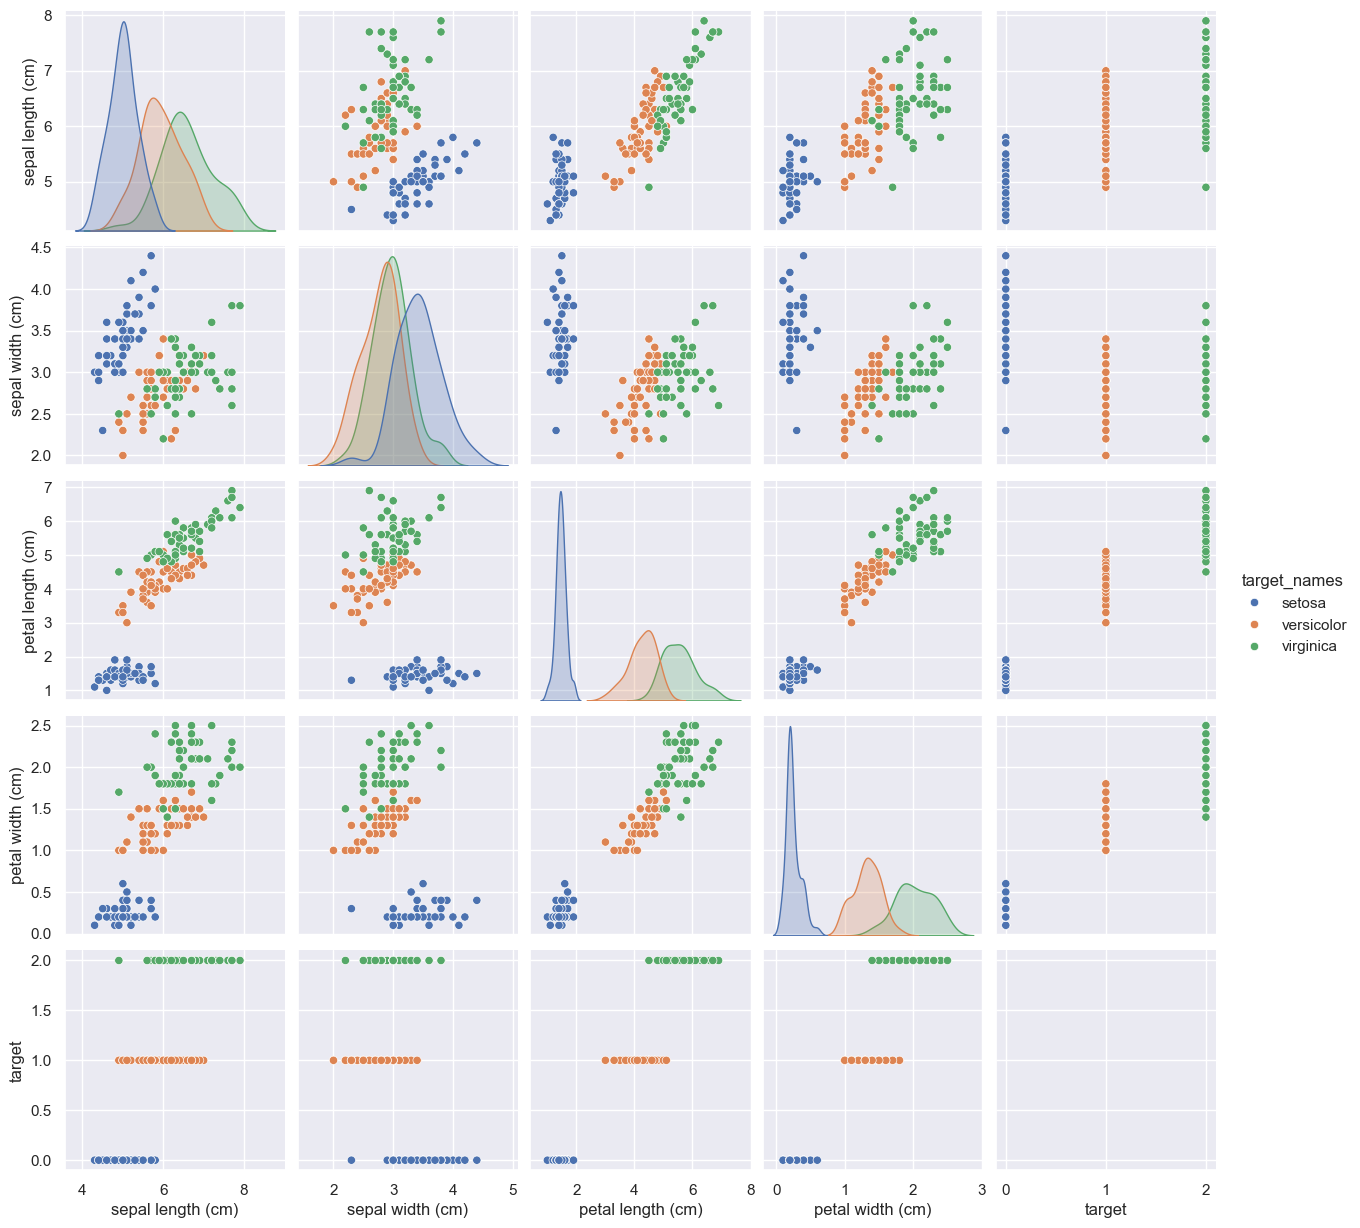

In [911]:
sns.pairplot(df, hue = 'target_names')

# Train/Test Split

In [912]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.25, random_state=42)

In [913]:
df_train.shape

(112, 6)

In [914]:
df_test.shape

(38, 6)

In [915]:
df_train.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
4,5.0,3.6,1.4,0.2,0,setosa
32,5.2,4.1,1.5,0.1,0,setosa
142,5.8,2.7,5.1,1.9,2,virginica
85,6.0,3.4,4.5,1.6,1,versicolor
86,6.7,3.1,4.7,1.5,1,versicolor


# Prepare our data for modeling

In [916]:
X_train = df_train.drop(columns = ['target', 'target_names']).values
y_train = df_train['target'].values
print(X_train.shape)
print(y_train.shape)

(112, 4)
(112,)


In [917]:
X_train
y_train

array([0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2, 1, 0, 2, 1, 0, 0, 0, 1,
       2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 2, 2, 1, 1, 2, 1, 0, 1, 2, 0,
       0, 1, 1, 0, 2, 0, 0, 1, 1, 2, 1, 2, 2, 1, 0, 0, 2, 2, 0, 0, 0, 1,
       2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2, 1, 1, 1, 0, 1, 1, 0, 1,
       2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 2, 1, 1, 2, 2, 0, 1, 2, 0,
       1, 2])

# Modeling - What is our baseline?
well, baseline is the floor result we can say kinda, Either we can guess every time (yeah this is also can be some kind of model)  or since we have 3 classes perfectly evenly balanced, we can just say one class everytime, resulting third of the results matching, giving us 33% accuracy. Therefore, our model should beat at least that level of accuracy

# Modeling - Simple manual modeling

In [918]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [919]:
def single_feature_prediction(pedal_length):
    if pedal_length < 2.5:
        return 0
    elif pedal_length < 4.8:
        return 1
    else:
        return 2
    

In [920]:
X_train[:, 2]

array([1.4, 1.5, 5.1, 4.5, 4.7, 1.3, 1.5, 3.7, 5.1, 5.5, 4.4, 6.1, 4.2,
       6.6, 4.5, 1.4, 6.7, 4.1, 1.4, 1.3, 1.9, 3.5, 4.9, 1.9, 1.6, 1.7,
       4.2, 1.5, 4.2, 6.7, 1.4, 4.3, 5. , 1.4, 4.8, 5.1, 4. , 4.5, 5.4,
       4. , 1.7, 3.3, 5.3, 1.4, 1.2, 3.8, 5. , 1.5, 5.1, 1.5, 1.6, 4.8,
       3. , 5.7, 5.1, 5.6, 6.1, 4. , 1.4, 1.1, 5. , 6. , 1.5, 1.4, 1.3,
       4.9, 5.6, 1.4, 5.5, 6. , 1.3, 4.7, 4.6, 4.8, 4.7, 5.3, 1.6, 5.4,
       4.2, 5.2, 3.5, 3.9, 4.6, 1.3, 4.6, 4.4, 1.5, 4.1, 6.3, 5.7, 1.5,
       3.3, 5.7, 5.8, 1.4, 5.6, 1.4, 4.9, 6.1, 5.6, 4.1, 5.5, 4.4, 4.3,
       4.9, 5.1, 1.7, 4. , 4.5, 1.2, 4. , 5.9])

In [921]:
manual_y_predictions = np.array([single_feature_prediction(val) for val in X_train[:, 2]])

In [922]:
manual_model_accuracy = np.mean(manual_y_predictions == y_train)

In [923]:
print(f"Manual model accuracy : {manual_model_accuracy*100:.2f}%")

Manual model accuracy : 94.64%


# Modeling - Logistic Regression

In [924]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=200)

In [925]:
Xt, Xv, yt, yv = train_test_split(X_train, y_train, random_state = 42, test_size=0.25)

In [926]:
model.fit(Xt, yt)

LogisticRegression(max_iter=200)

In [927]:
y_pred = model.predict(Xv)
np.mean(y_pred == yv)

np.float64(1.0)

In [928]:
model.score(Xv, yv)

1.0

### Using cross validation to evaluate our model

In [929]:
from sklearn.model_selection import cross_val_predict, cross_val_score
model = LogisticRegression(max_iter = 200)

In [930]:
accuracies = cross_val_score(model, X_train, y_train, cv = 5, scoring='accuracy')
accuracies

array([1.        , 1.        , 0.86363636, 1.        , 0.95454545])

In [931]:
np.mean(accuracies)

np.float64(0.9636363636363636)

# Where are we misclassifying points?

In [932]:
y_pred = cross_val_predict(model, X_train, y_train, cv = 5)

In [933]:
predicted_correctly = y_pred == y_train
len(predicted_correctly)

112

In [934]:
predicted_inccorrectly = ~predicted_correctly

In [935]:
X_train[predicted_inccorrectly]

array([[6.7, 3. , 5. , 1.7],
       [5.9, 3.2, 4.8, 1.8],
       [6. , 2.7, 5.1, 1.6],
       [4.9, 2.5, 4.5, 1.7]])

In [936]:
df_predictions = df_train.copy()
df_predictions.shape

(112, 6)

In [937]:
df_predictions['correct_prediction'] = predicted_correctly
df_predictions.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names,correct_prediction
4,5.0,3.6,1.4,0.2,0,setosa,True
32,5.2,4.1,1.5,0.1,0,setosa,True
142,5.8,2.7,5.1,1.9,2,virginica,True
85,6.0,3.4,4.5,1.6,1,versicolor,True
86,6.7,3.1,4.7,1.5,1,versicolor,True


In [938]:
df_predictions['prediction'] = y_pred
df_predictions['prediction_label'] = df_predictions['prediction'].map({0:'setosa', 1:'versicolor', 2:'virginica'})
df_predictions.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names,correct_prediction,prediction,prediction_label
4,5.0,3.6,1.4,0.2,0,setosa,True,0,setosa
32,5.2,4.1,1.5,0.1,0,setosa,True,0,setosa
142,5.8,2.7,5.1,1.9,2,virginica,True,2,virginica
85,6.0,3.4,4.5,1.6,1,versicolor,True,1,versicolor
86,6.7,3.1,4.7,1.5,1,versicolor,True,1,versicolor


In [939]:
print(X_train.shape)
print(y_train.shape)
print(df_train.shape)

(112, 4)
(112,)
(112, 6)


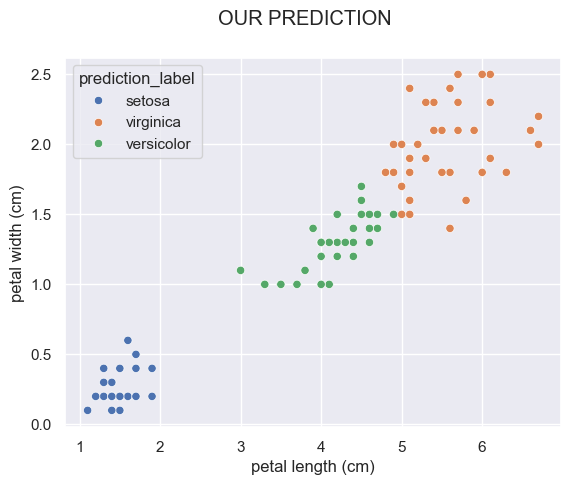

In [940]:
sns.scatterplot(x = 'petal length (cm)', y='petal width (cm)', hue='prediction_label', data = df_predictions)
plt.suptitle('OUR PREDICTION')
plt.show()

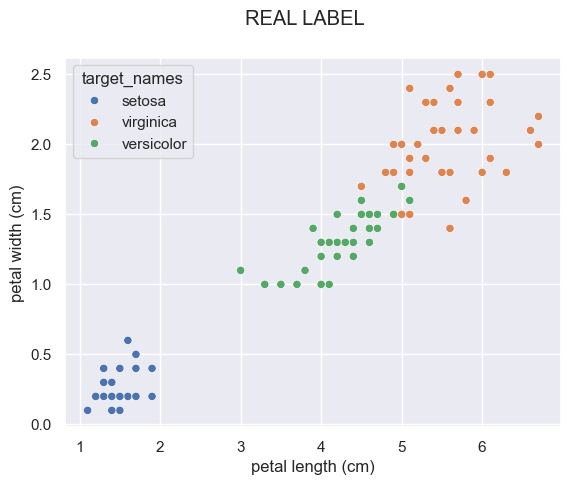

In [941]:
sns.scatterplot(x = 'petal length (cm)', y='petal width (cm)', hue='target_names', data = df_predictions)
plt.suptitle('REAL LABEL')
plt.show()

In [942]:
def plot_incorrect_predictions(df_predictions, x_axis_feature, y_axis_feature):
    fig, axs = plt.subplots(2,2, figsize = (10,10))
    axs = axs.flatten()    
    sns.scatterplot(x = x_axis_feature, y = y_axis_feature, hue = 'prediction_label', data = df_predictions, ax = axs[0])
    sns.scatterplot(x = x_axis_feature, y = y_axis_feature, hue = 'target_names', data = df_predictions, ax = axs[1])
    sns.scatterplot(x = x_axis_feature, y = y_axis_feature, hue = 'correct_prediction', data = df_predictions, ax = axs[2])
    axs[3].set_visible(False)

    plt.show()

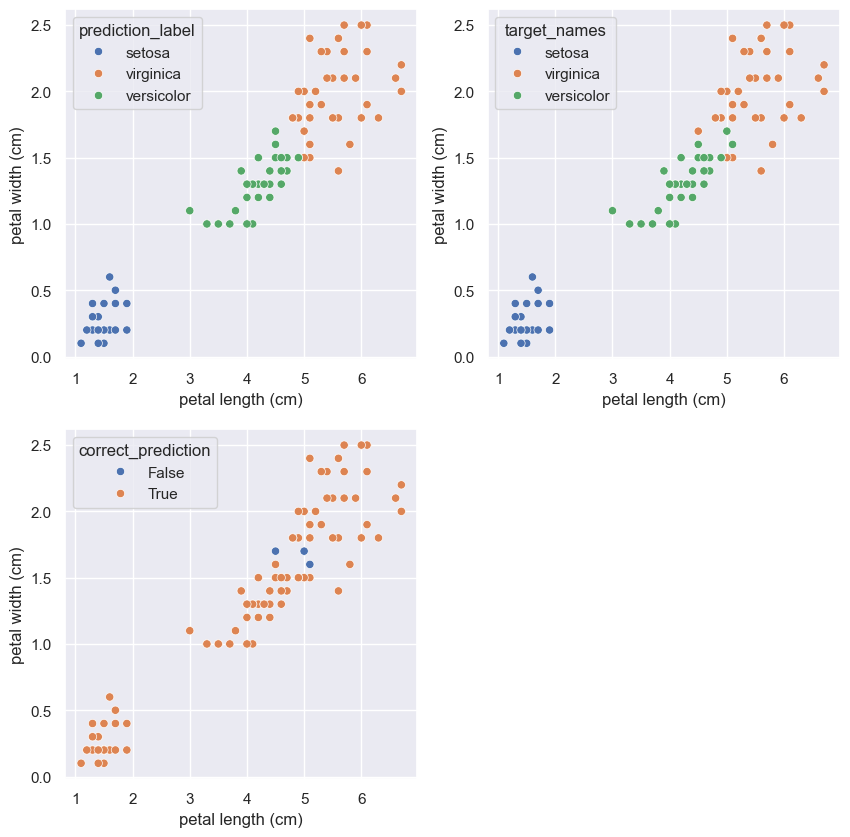

In [943]:
plot_incorrect_predictions(df_predictions, 'petal length (cm)', 'petal width (cm)')

# Model tuning

In [944]:
for reg_param in (0.1, 0.3, 0.9, 1, 1.3, 1.8, 2.3, 2.8, 3, 3.4, 4):
    print(reg_param)
    model = LogisticRegression(max_iter=200, C = reg_param)
    accuracies = cross_val_score(model, X_train, y_train,cv=5, scoring='accuracy')
    print(f"Accuracy: {np.mean(accuracies) * 100:.2f}%")

0.1
Accuracy: 92.77%
0.3
Accuracy: 93.68%
0.9
Accuracy: 96.36%
1
Accuracy: 96.36%
1.3
Accuracy: 96.36%
1.8
Accuracy: 96.36%
2.3
Accuracy: 96.36%
2.8
Accuracy: 94.58%
3
Accuracy: 94.58%
3.4
Accuracy: 94.58%
4
Accuracy: 94.58%


# Final Model

In [945]:
model = LogisticRegression(max_iter = 200, C = 1)


# How well does our model on the Test Set?

In [946]:
X_test = df_test.drop(columns = ['target', 'target_names']).values
y_test = df_test['target'].values

In [947]:
print(X_test.shape)
print(y_test.shape)

(38, 4)
(38,)


In [948]:
y_test

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0])

## Train our final model using our full Training Dataset

In [949]:
model.fit(X_train, y_train)

LogisticRegression(C=1, max_iter=200)

In [950]:
y_test_pred = model.predict(X_test)

In [951]:
test_set_correctly_classified = y_test_pred == y_test  
test_set_accuracy = np.mean(test_set_correctly_classified)

In [952]:
print(f"Test set accuracy: {test_set_accuracy * 100:.2f}%")

Test set accuracy: 100.00%


In [953]:
test_set_correctly_classified

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

In [954]:
df_predictions_test = df_test.copy()
df_predictions_test['correct_prediction'] = test_set_correctly_classified
df_predictions_test['prediction'] = y_test_pred
df_predictions_test['prediction_label'] = df_predictions_test['prediction'].map({0:'setosa', 1:'versicolor', 2:'virginica'})

In [955]:
df_predictions_test.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names,correct_prediction,prediction,prediction_label
11,4.8,3.4,1.6,0.2,0,setosa,True,0,setosa
42,4.4,3.2,1.3,0.2,0,setosa,True,0,setosa
146,6.3,2.5,5.0,1.9,2,virginica,True,2,virginica
51,6.4,3.2,4.5,1.5,1,versicolor,True,1,versicolor
27,5.2,3.5,1.5,0.2,0,setosa,True,0,setosa


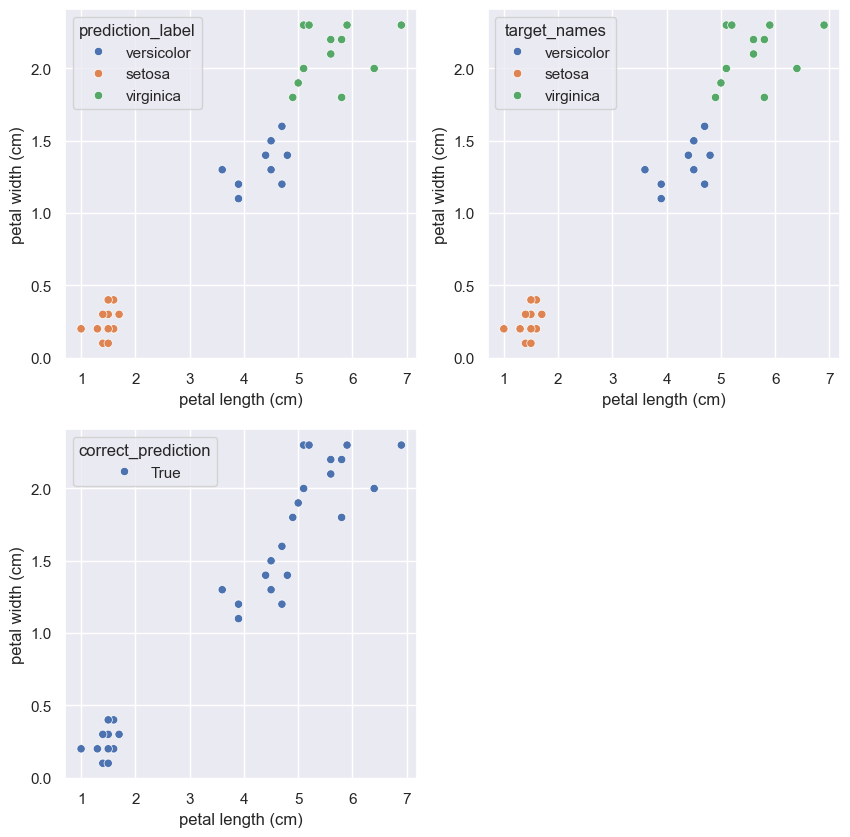

In [956]:
plot_incorrect_predictions(df_predictions_test, x_axis_feature = 'petal length (cm)', y_axis_feature='petal width (cm)')

# Conlusion:
Well, started kinda 33% baseline model, and our final model: 
```
model = LogisticRegression(max_iter = 200, C = 0.3)
```
go up to 96.36% accuracy on training dataset, and performed 100% on the test (unseen data). (There is definitely lucks splitting happened :))